# Spatio-Temporal Neural Estimator for Sea Surface Temperature
## Notebook: Data Preprocessing

**Author:** Wejdan Alharthi  
**Built with:** `NeuralEstimators.jl`

---

## 📌 Overview
This notebook prepares a **simulated spatio-temporal dataset** for neural inference. The goal is to generate structured data and organize it for model training.

---

## 🧬 Data Generation
We simulate data from a **Spatio-Temporal Gaussian Random Field (GRF)** using the following parameters:

* **$\theta_1$ (Spatial Range):** Controls spatial correlation.
* **$\theta_2$ (Temporal Dependence):** Controls AR(1) temporal dynamics.

**Simulation Steps:**
1.  Sampling parameters from a prior distribution.
2.  Simulating spatial fields using a **Matérn covariance**.
3.  Applying **AR(1) dynamics** over time.
4.  Computing **first differences** to ensure exchangeability.

---

## 📊 Dataset Structure

| Split | Samples |
| :--- | :--- |
| **Train** | 10,000 |
| **Val** | 1,000 |
| **Test** | 500 |

### **Sample Dimensions**
Each sample follows the tensor format: `(21, 21, 1, T)`
* **Spatial Grid:** $21 \times 21$
* **Channel:** 1
* **Time Steps:** Variable ($T \in [9, 29]$)

> **⚠️ Key Observation:** The temporal length varies across samples due to random simulation (originally $T \in [10, 30]$ before first differencing). This variability will be addressed during the preprocessing stage.

---

## 📂 Data Storage Strategy
The data is organized into two distinct stages:

### **1. Raw Data (Variable $T$)**
Stored in `data/raw/`
* `train_raw.jld2`
* `val_raw.jld2`
* `test_raw.jld2`

### **2. Processed Data (Fixed $T$)**
Stored in `data/processed/`
* `train_processed.jld2`
* `val_processed.jld2`
* `test_processed.jld2`

---

## 🚀 Next Steps
1.  **Temporal Alignment:** Fix temporal length using cropping or padding.
2.  **Tensor Preparation:** Convert processed data into model-ready tensors.
3.  **Model Definition:** Implement a **DeepSet + CNN** architecture for neural estimation.

---

## 📝 Summary
* ✅ Simulated **10,000+** spatio-temporal samples.
* ✅ Applied **first-difference** transformation for statistical consistency.
* ✅ Organized data into standardized **train/val/test** splits.
* ✅ Saved raw datasets ready for the next preprocessing pipeline.

## Environment Setup

This section initializes the project environment and loads all required packages.

We use a local Julia environment to ensure reproducibility and consistent dependencies across experiments.

---

### Steps

1. Activate the project environment  
2. Install required dependencies (if not already installed)  
3. Load all necessary libraries for:
   - Data simulation  
   - Preprocessing  
   - Visualization  
   - Saving datasets  

> Note: `Pkg.instantiate()` ensures that all dependencies listed in the project are installed correctly.

In [1]:
using Pkg
Pkg.activate("C:/Users/wejda/Documents/NBE")
Pkg.instantiate()

  Activating project at `C:\Users\wejda\Documents\NBE`


In [ ]:
using Folds
using Flux
using JLD2
using NeuralEstimators
using NeuralEstimators: getobs, numobs
using Distances
using Distributions: Uniform
using LinearAlgebra
using Statistics
using CairoMakie
using NamedArrays
using BSON
using Measures

┌ Error: You are using CUDA 13.0.0, but CUDA.jl was precompiled for CUDA 13.2.0.
│ This is unexpected; please file an issue.
└ @ CUDA C:\Users\wejda\.julia\packages\CUDA\Il00B\src\initialization.jl:148


## Part 1: Constructing a Neural Estimator for Spatio-Temporal SST Data

### Statistical Model

We model Sea Surface Temperature (SST) as a **Spatio-Temporal Gaussian Random Field (GRF)** with:

- Spatial dependence defined by a **Matérn covariance function** (ν = 1.5)  
- Temporal dependence defined by an **AR(1) process**

The model is governed by two parameters:

- **θ₁ (Spatial Range):** controls spatial correlation  
- **θ₂ (Temporal Dependence):** controls temporal persistence  

---

### Why Neural Inference?

Likelihood-based inference is computationally expensive due to repeated **Cholesky decompositions**.

Instead, we use **Simulation-Based Inference (SBI)** via NeuralEstimators:

- No likelihood evaluation required  
- Training is performed once  
- Inference is fast and scalable  

> Training is performed on an **RTX 4070 GPU** using 10,000 simulated samples.

---

### Sampler and Simulator

#### Prior

Parameters are sampled independently:

$$
\theta_1 \sim \text{Uniform}(0.05, 0.5), \quad
\theta_2 \sim \text{Uniform}(0.1, 0.9)
$$

---

#### Simulator

Spatio-temporal fields are generated using an AR(1) process:

$$
\mathbf{Z}_t = \theta_2 \mathbf{Z}_{t-1} + \boldsymbol{\varepsilon}_t
$$

where:

$$
\boldsymbol{\varepsilon}_t \sim \mathcal{N}(\mathbf{0}, (1 - \theta_2^2)\boldsymbol{\Sigma})
$$

and $\boldsymbol{\Sigma}$ is defined by the Matérn covariance with parameter θ₁.

---

### Exchangeability

Raw fields are **not exchangeable** due to temporal dependence.  
To address this, we compute **first differences**:

$$
\Delta_t = \mathbf{Z}_t - \mathbf{Z}_{t-1}
$$

This transformation makes the data suitable for a **DeepSet + CNN** architecture.

---

> Simulation is parallelized using `Folds.jl`.

In [3]:
using LinearAlgebra
using Distances
using NeuralEstimators
using NeuralEstimators: getobs, numobs

# -----------------------------
# Grid configuration
# -----------------------------
const grid_size = 21

const locs = [(i / grid_size, j / grid_size)
              for i in 1:grid_size
              for j in 1:grid_size]

const n_spatial = length(locs)

println("Grid size: ", grid_size, " × ", grid_size)
println("Number of spatial locations: ", n_spatial)

Grid size: 21 × 21
Number of spatial locations: 441


In [4]:
using Folds
using Distributions: Uniform

# -----------------------------
# Precompute pairwise distances
# -----------------------------
const dist_matrix = [norm(collect(locs[i]) .- collect(locs[j]))
                     for i in 1:n_spatial, j in 1:n_spatial]

# -----------------------------
# Matérn covariance (ν = 1.5)
# -----------------------------
function matern15(d, ρ)
    d == 0.0 && return 1.0
    r = sqrt(3) * d / ρ
    return (1 + r) * exp(-r)
end

# -----------------------------
# First differences
# -----------------------------
function firstdifference(Z)
    getobs(Z, 2:numobs(Z)) - getobs(Z, 1:numobs(Z)-1)
end

# -----------------------------
# Prior
# -----------------------------
function sampler(K)
    θ₁ = rand(Uniform(0.05, 0.5), K)
    θ₂ = rand(Uniform(0.1, 0.9), K)
    return Float32.(vcat(θ₁', θ₂'))
end

# -----------------------------
# Simulator
# -----------------------------
function simulate_one(θ::AbstractVector, T::Integer)
    ρ = θ[1]
    φ = θ[2]

    Σ = matern15.(dist_matrix, ρ)
    L = cholesky(Σ + 1e-6 * I).L

    Z = zeros(n_spatial, T)
    Z[:, 1] = L * randn(n_spatial)

    for t in 2:T
        Z[:, t] = φ .* Z[:, t-1] .+ sqrt(1 - φ^2) .* (L * randn(n_spatial))
    end

    Z = reshape(Z, grid_size, grid_size, 1, T)
    return firstdifference(Z)
end

simulate_one(θ::AbstractVector, T::UnitRange{Int}) = simulate_one(θ, rand(T))

simulate(θ::AbstractMatrix, T = 10:30) =
    Folds.map(ϑ -> simulate_one(ϑ, T), eachcol(θ))

simulate (generic function with 2 methods)

In [5]:
θ_test = sampler(3)
Z_test = simulate(θ_test, 10:30)

println("Number of samples: ", length(Z_test))
println("Theta shape: ", size(θ_test))
println("First sample shape: ", size(Z_test[1]))

Number of samples: 3
Theta shape: (2, 3)
First sample shape: (21, 21, 1, 20)


### Data Format and Verification

#### Data Format

The dataset is structured to match the **DeepSet + CNN** architecture:

- **θ:** matrix of shape `2 × N` (each column is `[θ₁, θ₂]`)  
- **Z:** vector of length `N`, where each element is a `(21, 21, 1, T)` tensor  
- **T:** variable temporal length (after differencing, \( T \in [9, 29] \))  

---

#### Verification

Before training, we visualize simulated samples to verify that:

- **θ₁** controls spatial smoothness  
- **θ₂** controls temporal persistence  

This step ensures that the simulator behaves as expected before training the neural estimator.

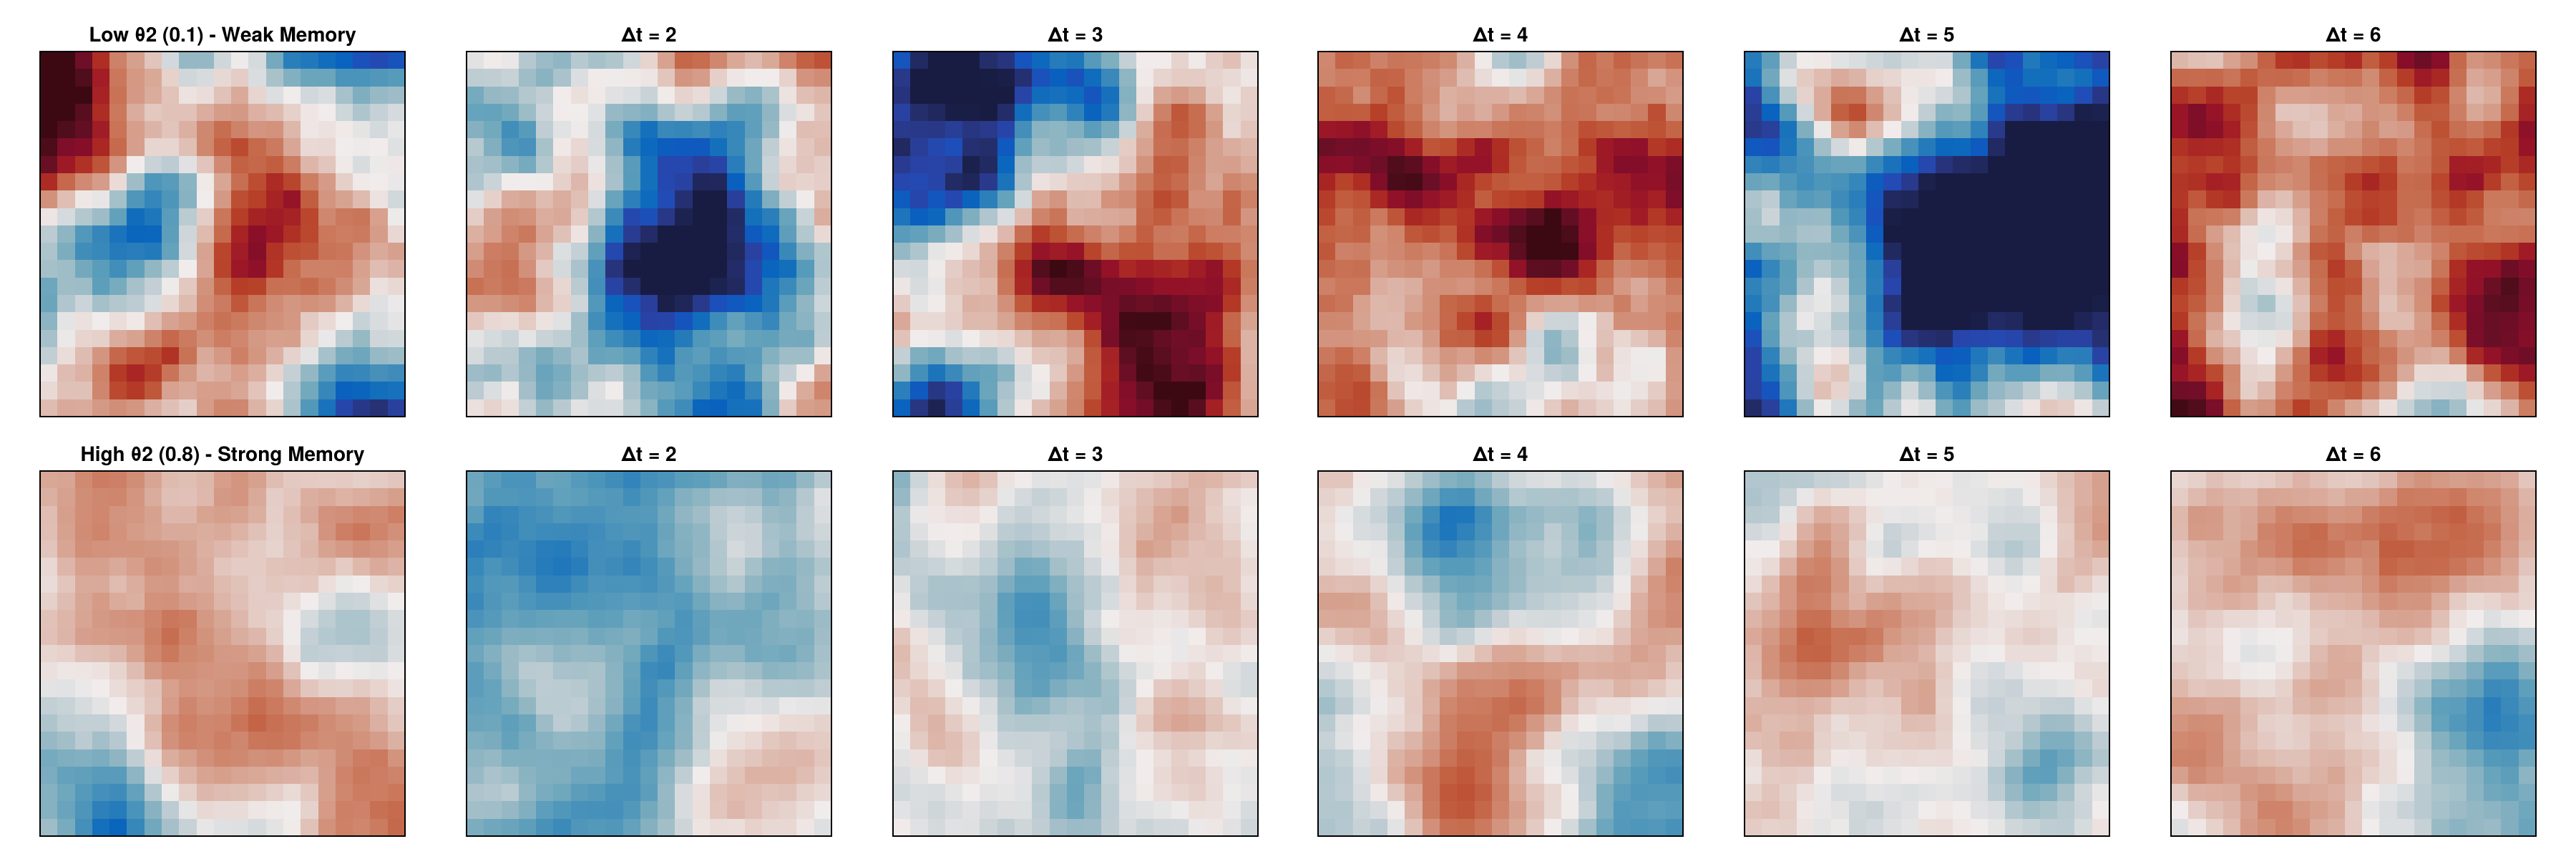

CairoMakie.Screen{IMAGE}


In [7]:
using CairoMakie

# --- Visualization: Effect of θ2 (Temporal Range) ---

# 1. Fix θ1 = 0.3, vary θ2
theta_viz = Float32[0.3  0.3;
                    0.1  0.8]

# 2. Simulate with fixed T = 7 (gives 6 differences)
Z_viz = simulate(theta_viz, 7:7)

labels = ["Low θ2 (0.1) - Weak Memory", "High θ2 (0.8) - Strong Memory"]

fig = Figure(size = (1800, 600))

for k in 1:2
    Z_k = Z_viz[k]   # (21, 21, 1, 6)
    ntime_viz = size(Z_k, 4)

    for t in 1:ntime_viz
        ax = Axis(fig[k, t],
            title = (t == 1 ? labels[k] : "Δt = $t"),
            aspect = DataAspect())

        hidedecorations!(ax)
        heatmap!(ax, Z_k[:, :, 1, t],
            colormap = :balance,
            colorrange = (-2.5, 2.5))
    end
end

display(fig)

### Analysis of Spatio-Temporal Dynamics

The visualization confirms that the simulator captures the effect of θ₂ on the **first-difference fields** ΔZ:

- **Low θ₂ (0.1):** larger, more variable differences → weak temporal dependence  
- **High θ₂ (0.8):** smaller, smoother differences → strong temporal dependence  

This behavior reflects how temporal correlation influences the magnitude of successive changes.

The **DeepSet + CNN** architecture leverages this structure by processing difference fields and aggregating information across time to infer the underlying parameters.

### Step 2: Dataset Construction

We generate samples from the joint distribution:

$$
p(\theta, Z) = p(\theta)\, p(Z \mid \theta)
$$

The dataset is split as follows:

| Dataset | Samples | Purpose |
|--------|--------|--------|
| Train  | 10,000 | Model training |
| Val    | 1,000  | Validation |
| Test   | 500    | Evaluation |

Each sample consists of:

- A parameter vector $\theta = [\theta_1, \theta_2]^\top$  
- A sequence of first-difference fields $\{\Delta_t\}$  

The temporal length is randomly sampled with:
$$
T \in \{10, \ldots, 30\}
$$

---

### Verification

After generation, we verify:

- Number of samples in each split  
- Shape of $\theta$  
- Shape of simulated fields  
- Range of temporal length \(T\)

This ensures that the dataset is correctly generated before preprocessing and training.

> Simulation is parallelized using `Folds.jl`.

In [10]:
# -----------------------------
# Generate train / val / test sets
# -----------------------------
println("Generating training set (10,000 samples)...")
@time theta_train = sampler(10_000)
@time Z_train = simulate(theta_train, 10:30)

println("Generating validation set (1,000 samples)...")
@time theta_val = sampler(1_000)
@time Z_val = simulate(theta_val, 10:30)

println("Generating test set (500 samples)...")
@time theta_test = sampler(500)
@time Z_test = simulate(theta_test, 10:30)

println("Done!")

println("Train samples: ", length(Z_train), " | theta shape: ", size(theta_train))
println("Val samples: ", length(Z_val), " | theta shape: ", size(theta_val))
println("Test samples: ", length(Z_test), " | theta shape: ", size(theta_test))

println("Example train sample shape: ", size(Z_train[1]))
println("Example val sample shape: ", size(Z_val[1]))
println("Example test sample shape: ", size(Z_test[1]))

Generating training set (10,000 samples)...
  0.000149 seconds (20 allocations: 391.434 KiB)
 22.103238 seconds (2.58 M allocations: 63.162 GiB, 43.80% gc time)
Generating validation set (1,000 samples)...
  0.000032 seconds (20 allocations: 39.902 KiB)
  2.559123 seconds (252.71 k allocations: 6.302 GiB, 54.36% gc time)
Generating test set (500 samples)...
  0.000018 seconds (20 allocations: 20.465 KiB)
  0.997526 seconds (132.34 k allocations: 3.164 GiB, 47.42% gc time)
Done!
Train samples: 10000 | theta shape: (2, 10000)
Val samples: 1000 | theta shape: (2, 1000)
Test samples: 500 | theta shape: (2, 500)
Example train sample shape: (21, 21, 1, 27)
Example val sample shape: (21, 21, 1, 16)
Example test sample shape: (21, 21, 1, 25)


In [9]:
function check_time_lengths(name, Z)
    lengths = [size(x, 4) for x in Z]
    println(name, " min T = ", minimum(lengths), " | max T = ", maximum(lengths))
end

check_time_lengths("train", Z_train)
check_time_lengths("val", Z_val)
check_time_lengths("test", Z_test)

train min T = 9 | max T = 29
val min T = 9 | max T = 29
test min T = 9 | max T = 29


### Step 3: Saving the Dataset

After generating and verifying the dataset, we store it for later use.

The data is saved in **raw format**, preserving the variable temporal length \(T\).  
This allows flexibility for different preprocessing strategies in the next stage.

Each split is saved separately:

``` id="rawdata"
data/raw/
├── train_raw.jld2
├── val_raw.jld2
└── test_raw.jld2 
```
**Each file contains:**

* **Parameter matrix $\theta$:** The ground-truth parameters used for simulation.
* **Corresponding simulated data $Z$:** The spatio-temporal fields generated for each sample.

---

### Verification
We confirm that the files are successfully saved and accessible before proceeding to preprocessing.

In [14]:
using JLD2

@save "data/raw/train_raw.jld2" Z_train theta_train
@save "data/raw/val_raw.jld2"   Z_val theta_val
@save "data/raw/test_raw.jld2"  Z_test theta_test

In [15]:
readdir("data/raw")

3-element Vector{String}:
 "test_raw.jld2"
 "train_raw.jld2"
 "val_raw.jld2"

### Step 4: Data Preprocessing

The raw simulated dataset contains samples with **variable temporal length**.  
Before training, we preprocess the data to obtain a consistent input format.

In this step, we:

1. Load the raw train, validation, and test sets  
2. Inspect the temporal length across samples  
3. Fix a common temporal length  
4. Truncate each sample to this shared length  
5. Verify that all processed samples have the same shape  
6. Save the processed datasets for model training

This ensures that the input data is consistent and ready for the next stage.

In [17]:
using JLD2

# --- Load Simulated Datasets ---
# Each file contains:
# Z: The simulated spatio-temporal fields (data)
# theta (θ): The ground-truth parameters used for simulation

# Load Training set
@load "data/raw/train_raw.jld2" Z_train theta_train

# Load Validation set
@load "data/raw/val_raw.jld2"   Z_val theta_val

# Load Test set
@load "data/raw/test_raw.jld2"  Z_test theta_test

2-element Vector{Symbol}:
 :Z_test
 :theta_test

In [18]:
# Function to verify the variability of the temporal dimension (T) across samples
function check_time_lengths(name, Z)
    # Extract the temporal length (4th dimension) for each sample in the dataset
    lengths = [size(x, 4) for x in Z]
    
    # Print the range of time steps (min and max T) to confirm simulation consistency
    println(name, " min T = ", minimum(lengths), " | max T = ", maximum(lengths))
end

# Verify temporal dimensions for Train, Validation, and Test sets
check_time_lengths("train", Z_train)
check_time_lengths("val", Z_val)
check_time_lengths("test", Z_test)

train min T = 9 | max T = 29
val min T = 9 | max T = 29
test min T = 9 | max T = 29


In [19]:
# Define a uniform temporal length (T) for data alignment/standardization
# All samples will be cropped or padded to this fixed size (9) for model input
T_fixed = 9
println("Using fixed temporal length: ", T_fixed)

Using fixed temporal length: 9


In [20]:
# --- Temporal Truncation / Data Alignment ---

"""
Function: truncate_time
Purpose: Standardizes the temporal dimension by slicing all samples to a fixed length.
Arguments:
  - Z: Vector of 4D arrays (Spatio-temporal samples)
  - T_fixed: The target number of time steps (e.g., 9)
"""
function truncate_time(Z, T_fixed)
    # Use list comprehension to slice each sample x at the 4th dimension from index 1 to T_fixed
    return [x[:, :, :, 1:T_fixed] for x in Z]
end

# Apply truncation to all datasets to ensure consistent tensor shapes for the model
Z_train_processed = truncate_time(Z_train, T_fixed)
Z_val_processed   = truncate_time(Z_val, T_fixed)
Z_test_processed  = truncate_time(Z_test, T_fixed)

500-element Vector{Array{Float64, 4}}:
 [-1.564799299950363 -1.2237439340610785 … -2.1455416354294004 -2.368982025521908; -0.9357725008697586 -1.3799471570860933 … -1.9968003210118577 -2.017759598240592; … ; -0.14580254152193461 -0.06123549133161435 … 0.28773894219454815 0.5640259809026723; 0.6737022541369635 0.4583901379206553 … 0.2223964768381162 0.5199120544409522;;;; -0.016422882894380653 -0.026511723451899893 … 1.2569035945305063 1.3481882461571217; -0.3842974172131792 0.040968627686182146 … 1.0310298259211692 1.006301317936095; … ; 0.4911671198536374 0.24487529432796593 … -1.4532166629279981 -0.8800803289849444; 0.06901961251972 0.04124053512875325 … -1.1507795329080828 -0.8675829514846105;;;; 0.623665868281166 1.317401397994083 … 0.8867937524482156 1.2803817893801555; 1.123633837253557 1.1850031129509198 … 1.1338630121077249 1.4538733031191668; … ; -1.0888903680120288 -0.6159433466849084 … 0.82013685347234 0.22972856057795604; -0.7756818761787221 -0.3726557502507512 … 0.50130564

In [21]:
function check_consistent_shapes(name, Z)
    ref = size(Z[1])
    ok = all(size(x) == ref for x in Z)
    println(name, " consistent shapes? ", ok, " | ref = ", ref)
end

check_consistent_shapes("train", Z_train_processed)
check_consistent_shapes("val", Z_val_processed)
check_consistent_shapes("test", Z_test_processed)

train consistent shapes? true | ref = (21, 21, 1, 9)
val consistent shapes? true | ref = (21, 21, 1, 9)
test consistent shapes? true | ref = (21, 21, 1, 9)


In [22]:
# --- Save Processed Datasets (Fixed Temporal Length) ---

# All samples now have a uniform temporal dimension (T = 9).
# These files are ready for neural network training and batch processing.

# Save processed training set with its original parameters
@save "data/processed/train_processed.jld2" Z_train_processed theta_train

# Save processed validation set
@save "data/processed/val_processed.jld2"   Z_val_processed theta_val

# Save processed test set
@save "data/processed/test_processed.jld2"  Z_test_processed theta_test

In [23]:
# --- Final Verification: File System Check ---

# List all files in the processed data directory to confirm that 
# the .jld2 datasets were generated and saved correctly.
readdir("data/processed")

3-element Vector{String}:
 "test_processed.jld2"
 "train_processed.jld2"
 "val_processed.jld2"

### Preprocessing Result

After truncation, all samples have a consistent temporal length.

The processed datasets now share the same input shape:

- **Train:** `(21, 21, 1, 9)`
- **Validation:** `(21, 21, 1, 9)`
- **Test:** `(21, 21, 1, 9)`

This confirms that the preprocessing step was successful and that the data is now ready for model training.

> We use the minimum shared temporal length across all samples to ensure a consistent input format for training.